In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import hilbert, welch, butter, filtfilt
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest

# --- 1. Geração de Dados ---
def generate_subtle_data(n_normal=1000, n_anom=50):
    np.random.seed(42)
    nomes_sensores = ['Temp', 'Pressao', 'Vibracao', 'Corrente', 'Tensao', 'Velocidade']

    X_normal = np.column_stack([
        np.random.normal(50, 5, n_normal), np.random.normal(50, 10, n_normal),
        np.random.exponential(10, n_normal), np.random.normal(10, 2, n_normal),
        np.random.normal(220, 5, n_normal), np.random.poisson(50, n_normal)
    ])

    X_anom = np.column_stack([
        np.random.normal(58, 4, n_anom), np.random.normal(65, 8, n_anom),
        np.random.exponential(18, n_anom), np.random.normal(13, 2, n_anom),
        np.random.normal(230, 5, n_anom), np.random.poisson(60, n_anom)
    ])

    X = np.vstack((X_normal, X_anom))
    y = np.concatenate([np.zeros(n_normal), np.ones(n_anom)])
    return pd.DataFrame(X, columns=nomes_sensores), y

# --- 2. FUNÇÕES DSP pra gerar "score de anomalia" ---
def score_zscore(sinal, janela=100):
    """Quanto maior o zscore, maior a chance de ser anomalia"""
    # Changed from center=True to default (center=False, trailing window) for more robust baseline
    media = pd.Series(sinal).rolling(window=janela).mean()
    std = pd.Series(sinal).rolling(window=janela).std()
    z = np.abs((sinal - media) / std)
    return z.fillna(0)

def score_rms(sinal, janela=50):
    """Quanto maior o RMS, maior a chance de ser anomalia"""
    rms = pd.Series(sinal**2).rolling(window=janela).mean().apply(np.sqrt)
    return rms.fillna(0)

def score_kurtosis(sinal, janela=50):
    """Quanto maior a Kurtosis, maior a chance de ser anomalia"""
    kurt = pd.Series(sinal).rolling(window=janela).kurt()
    return kurt.fillna(0)

def score_envelope(sinal, fs=1000):
    """Energia do envelope. Quanto maior, maior a chance de ser anomalia"""
    b, a = butter(4, [100, 400], btype='band', fs=fs)
    sinal_filtrado = filtfilt(b, a, sinal)
    envelope = np.abs(hilbert(sinal_filtrado))
    freqs, psd = welch(envelope, fs=fs, nperseg=256)
    idx = np.where((freqs >= 50) & (freqs <= 200))[0]
    # Replicar o score pra todo o sinal
    energia = np.sum(psd[idx])
    return np.full_like(sinal, energia)

# --- Helper function to tune window size (SUPERVISED) ---
def _find_best_window_for_score(signal, y_true, score_fn, window_sizes_to_try=None):
    if window_sizes_to_try is None:
        # Default range if not specified
        window_sizes_to_try = range(10, 201, 10)

    best_pr_auc = -1
    best_window = None
    best_scores = None

    for window in window_sizes_to_try:
        if window > len(signal):
            continue
        current_scores = score_fn(signal, janela=window)
        # Handle cases where all scores might be 0 or nan leading to issues with average_precision_score
        if np.all(current_scores == 0) or np.any(np.isnan(current_scores)):
            current_pr_auc = 0.0
        else:
            current_pr_auc = average_precision_score(y_true, current_scores)

        if current_pr_auc > best_pr_auc:
            best_pr_auc = current_pr_auc
            best_window = window
            best_scores = current_scores

    # If no window size yields a PR-AUC > -1, return default or first computed value
    if best_scores is None and len(window_sizes_to_try) > 0:
        best_window = window_sizes_to_try[0]
        best_scores = score_fn(signal, janela=best_window)
        best_pr_auc = average_precision_score(y_true, best_scores)

    return best_pr_auc, best_window, best_scores

# --- Helper function to tune window size (UNSUPERVISED) ---
def _find_unsupervised_best_window_for_score(signal, score_fn, window_sizes_to_try=None):
    if window_sizes_to_try is None:
        window_sizes_to_try = range(10, 201, 10)

    best_unsupervised_metric = -np.inf # Initialize with negative infinity for maximization
    best_window = None
    best_scores = None

    for window in window_sizes_to_try:
        if window > len(signal):
            continue
        current_scores = score_fn(signal, janela=window)
        # Unsupervised metric: maximize the standard deviation of the scores.
        # Higher std implies a wider spread, potentially making anomalies more distinct.
        current_unsupervised_metric = np.std(current_scores)

        if current_unsupervised_metric > best_unsupervised_metric:
            best_unsupervised_metric = current_unsupervised_metric
            best_window = window
            best_scores = current_scores

    # Fallback if no valid window was found (unlikely with default range)
    if best_scores is None and len(window_sizes_to_try) > 0:
        best_window = window_sizes_to_try[0]
        best_scores = score_fn(signal, janela=best_window)

    return best_window, best_scores

# --- 3. CALCULAR PR-AUC PARA CADA VARIÁVEL (FUNÇÃO DE CÁLCULO) ---
def calcular_pr_auc_scores(df, y):
    resultados_pr = {}
    tecnicas_scores = {}
    optimal_params = {}

    print("--- PR-AUC por Variável DSP (Otimizado com janelas ainda mais expandidas e granularidade fina) ---")

    # Define a wider range for window sizes for Z-score features with finer granularity
    wider_window_range_fine_grained = range(10, len(df), 5)

    # Features using Z-score
    for feature in ['Temp', 'Pressao', 'Tensao', 'Velocidade']:
        pr_auc, window, scores = _find_best_window_for_score(df[feature], y, score_zscore,
                                                             window_sizes_to_try=wider_window_range_fine_grained)
        tecnicas_scores[feature] = scores
        resultados_pr[feature] = pr_auc
        optimal_params[feature] = {'method': 'zscore', 'janela': window}
        print(f"{feature:<20}: PR-AUC = {pr_auc:.4f} (Janela: {window})")

    # Features using RMS (keep default range for now, or consider wider too if needed)
    pr_auc_corr, window_corr, scores_corr = _find_best_window_for_score(df['Corrente'], y, score_rms)
    tecnicas_scores['Corrente'] = scores_corr
    resultados_pr['Corrente'] = pr_auc_corr
    optimal_params['Corrente'] = {'method': 'rms', 'janela': window_corr}
    print(f"{'Corrente':<20}: PR-AUC = {pr_auc_corr:.4f} (Janela: {window_corr})")

    pr_auc_vibr_rms, window_vibr_rms, scores_vibr_rms = _find_best_window_for_score(df['Vibracao'], y, score_rms)
    tecnicas_scores['Vibracao_RMS'] = scores_vibr_rms
    resultados_pr['Vibracao_RMS'] = pr_auc_vibr_rms
    optimal_params['Vibracao_RMS'] = {'method': 'rms', 'janela': window_vibr_rms}
    print(f"{'Vibracao_RMS':<20}: PR-AUC = {pr_auc_vibr_rms:.4f} (Janela: {window_vibr_rms})")

    # Features using Kurtosis (keep default range for now)
    pr_auc_vibr_kurt, window_vibr_kurt, scores_vibr_kurt = _find_best_window_for_score(df['Vibracao'], y, score_kurtosis)
    tecnicas_scores['Vibracao_Kurt'] = scores_vibr_kurt
    resultados_pr['Vibracao_Kurt'] = pr_auc_vibr_kurt
    optimal_params['Vibracao_Kurt'] = {'method': 'kurtosis', 'janela': window_vibr_kurt}
    print(f"{'Vibracao_Kurt':<20}: PR-AUC = {pr_auc_vibr_kurt:.4f} (Janela: {window_vibr_kurt})")

    # Features using Envelope (no window tuning for now)
    envelope_scores = score_envelope(df['Vibracao'].values)
    pr_auc_vibr_envelope = average_precision_score(y, envelope_scores)
    tecnicas_scores['Vibracao_Envelope'] = envelope_scores
    resultados_pr['Vibracao_Envelope'] = pr_auc_vibr_envelope
    optimal_params['Vibracao_Envelope'] = {'method': 'envelope'}
    print(f"{'Vibracao_Envelope':<20}: PR-AUC = {pr_auc_vibr_envelope:.4f}")

    return resultados_pr, tecnicas_scores, optimal_params

# --- FUNÇÃO PARA CALCULAR SCORES COM JANELA NÃO SUPERVISIONADA ---
def calcular_scores_com_janela_nao_supervisionada(df, y_real):
    resultados_pr_unsupervised_window = {}
    tecnicas_scores_unsupervised_window = {}
    optimal_params_unsupervised_window = {}

    print("\n--- Otimização de Janelas DSP com Critério NÃO Supervisionado (Maximizar Desvio Padrão dos Scores) ---")

    wider_window_range_fine_grained = range(10, len(df), 5)

    # Features using Z-score
    for feature in ['Temp', 'Pressao', 'Tensao', 'Velocidade']:
        window, scores = _find_unsupervised_best_window_for_score(df[feature], score_zscore,
                                                                  window_sizes_to_try=wider_window_range_fine_grained)
        # For comparison, calculate PR-AUC with y_real *after* the window was chosen unsupervisedly
        pr_auc = average_precision_score(y_real, scores)
        tecnicas_scores_unsupervised_window[feature] = scores
        resultados_pr_unsupervised_window[feature] = pr_auc
        optimal_params_unsupervised_window[feature] = {'method': 'zscore_unsupervised_window', 'janela': window}
        print(f"{feature:<20}: PR-AUC = {pr_auc:.4f} (Janela Não Supervisionada: {window})")

    # Features using RMS
    window_corr, scores_corr = _find_unsupervised_best_window_for_score(df['Corrente'], score_rms)
    pr_auc_corr = average_precision_score(y_real, scores_corr)
    tecnicas_scores_unsupervised_window['Corrente'] = scores_corr
    resultados_pr_unsupervised_window['Corrente'] = pr_auc_corr
    optimal_params_unsupervised_window['Corrente'] = {'method': 'rms_unsupervised_window', 'janela': window_corr}
    print(f"{'Corrente':<20}: PR-AUC = {pr_auc_corr:.4f} (Janela Não Supervisionada: {window_corr})")

    window_vibr_rms, scores_vibr_rms = _find_unsupervised_best_window_for_score(df['Vibracao'], score_rms)
    pr_auc_vibr_rms = average_precision_score(y_real, scores_vibr_rms)
    tecnicas_scores_unsupervised_window['Vibracao_RMS'] = scores_vibr_rms
    resultados_pr_unsupervised_window['Vibracao_RMS'] = pr_auc_vibr_rms
    optimal_params_unsupervised_window['Vibracao_RMS'] = {'method': 'rms_unsupervised_window', 'janela': window_vibr_rms}
    print(f"{'Vibracao_RMS':<20}: PR-AUC = {pr_auc_vibr_rms:.4f} (Janela Não Supervisionada: {window_vibr_rms})")

    # Features using Kurtosis
    window_vibr_kurt, scores_vibr_kurt = _find_unsupervised_best_window_for_score(df['Vibracao'], score_kurtosis)
    pr_auc_vibr_kurt = average_precision_score(y_real, scores_vibr_kurt)
    tecnicas_scores_unsupervised_window['Vibracao_Kurt'] = scores_vibr_kurt
    resultados_pr_unsupervised_window['Vibracao_Kurt'] = pr_auc_vibr_kurt
    optimal_params_unsupervised_window['Vibracao_Kurt'] = {'method': 'kurtosis_unsupervised_window', 'janela': window_vibr_kurt}
    print(f"{'Vibracao_Kurt':<20}: PR-AUC = {pr_auc_vibr_kurt:.4f} (Janela Não Supervisionada: {window_vibr_kurt})")

    # Features using Envelope (no window tuning)
    envelope_scores = score_envelope(df['Vibracao'].values)
    pr_auc_vibr_envelope = average_precision_score(y_real, envelope_scores)
    tecnicas_scores_unsupervised_window['Vibracao_Envelope'] = envelope_scores
    resultados_pr_unsupervised_window['Vibracao_Envelope'] = pr_auc_vibr_envelope
    optimal_params_unsupervised_window['Vibracao_Envelope'] = {'method': 'envelope'}
    print(f"{'Vibracao_Envelope':<20}: PR-AUC = {pr_auc_vibr_envelope:.4f}")

    print("\n--- Ranking de Separação (Janela Não Supervisionada) ---")
    df_rank_unsupervised_window = pd.DataFrame.from_dict(resultados_pr_unsupervised_window, orient='index', columns=['PR-AUC']).sort_values('PR-AUC', ascending=False)
    print(df_rank_unsupervised_window)

    return resultados_pr_unsupervised_window, tecnicas_scores_unsupervised_window, optimal_params_unsupervised_window

# --- FUNÇÃO PARA PLOTAR DISTRIBUIÇÕES ---
def plot_distribution_plots(df, y, optimal_params):
    all_features_to_plot = ['Temp', 'Pressao', 'Corrente', 'Tensao', 'Velocidade', 'Vibracao_RMS']

    plot_df = df.copy()
    plot_df['Anomalia'] = y

    fig = plt.figure(figsize=(18, 12)) # Adjust figure size for 6 subplots
    plt.suptitle('Distribuição das Características (Normal vs. Anomalia)', fontsize=16)

    for i, feature in enumerate(all_features_to_plot):
        ax = fig.add_subplot(2, 3, i + 1) # 2 rows, 3 columns

        if feature == 'Vibracao_RMS':
            # For 'Vibracao_RMS', we need to recalculate the scores using the optimal window
            # identified previously. Access optimal window from optimal_params dictionary
            optimal_window_vibracao_rms = optimal_params['Vibracao_RMS']['janela']
            vibracao_rms_scores = score_rms(df['Vibracao'], janela=optimal_window_vibracao_rms)

            # Create a temporary DataFrame for plotting Vibracao_RMS scores
            vibracao_rms_plot_df = pd.DataFrame({
                'Score RMS da Vibração': vibracao_rms_scores,
                'Anomalia': y
            })
            sns.histplot(data=vibracao_rms_plot_df, x='Score RMS da Vibração', hue='Anomalia', kde=True, palette='viridis', alpha=0.6,
                         common_norm=False, stat='density', linewidth=0, ax=ax)
            ax.set_title('Score RMS da Vibração')
            ax.set_xlabel('')
        else:
            sns.histplot(data=plot_df, x=feature, hue='Anomalia', kde=True, palette='viridis', alpha=0.6,
                         common_norm=False, stat='density', linewidth=0, ax=ax)
            ax.set_title(f'{feature}')
            ax.set_xlabel('')

        ax.set_ylabel('Densidade')
        ax.legend(title='Anomalia', labels=['Normal (0)', 'Anomalia (1)'], loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap, leaving space for suptitle
    plt.show()

# --- FUNÇÃO PARA PLOTAR CURVAS PR-AUC ---
def plot_pr_auc_curves(y, tecnicas_scores, resultados_pr, metrics_to_plot=None):
    # Plotar as curvas PR
    plt.figure(figsize=(10, 7))
    for nome, score in tecnicas_scores.items():
        if metrics_to_plot is None or nome in metrics_to_plot:
            # Print the exact value to confirm
            #print(f"Plotando {nome} com PR-AUC: {resultados_pr[nome]:.6f}") # Print with higher precision
            precision, recall, _ = precision_recall_curve(y, score)
            plt.plot(recall, precision, label=f'{nome} - {resultados_pr[nome]:.6f}') # Removed 'AP='

    plt.xlabel('Recall')
    plt.ylabel('Precisão') # Translated label
    plt.title('Curvas Precision-Recall por Variável DSP (Otimizado com janelas ainda mais expandidas e granularidade fina)')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 4. EXECUÇÃO (BLOCO PRINCIPAL) ---
if __name__ == "__main__":
    df, y_real = generate_subtle_data()
    selected_metrics = ['Temp', 'Pressao', 'Corrente', 'Tensao', 'Velocidade', 'Vibracao_RMS']

    print("\n### 3. Scores DSP com Seleção de Janela NÃO SupervisionADA (Otimizado por Desvio Padrão dos Scores) ###")
    # Calculate scores and parameters using unsupervised window selection
    resultados_pr_unsupervised_window, tecnicas_scores_unsupervised_window, optimal_params_unsupervised_window = \
        calcular_scores_com_janela_nao_supervisionada(df, y_real)

    print("\n### 4. Detecção de Anomalias Não Supervisionada com Isolation Forest (Usando Scores DSP de Janela NÃO Supervisionada) ###")
    print("Esta seção usa os scores DSP cujas janelas foram otimizadas de forma não supervisionada, e o Isolation Forest é treinado sem os rótulos.")

    # Criar um DataFrame com os scores das métricas selecionadas (de janela NÃO supervisionada)
    df_scores_if_unsupervised_window = pd.DataFrame({
        metric: tecnicas_scores_unsupervised_window[metric] for metric in selected_metrics
    })

    # Escalar os scores
    scaler_if_unsupervised_window = RobustScaler()
    df_scores_scaled_if_unsupervised_window = scaler_if_unsupervised_window.fit_transform(df_scores_if_unsupervised_window)
    df_scores_scaled_if_unsupervised_window = pd.DataFrame(df_scores_scaled_if_unsupervised_window, columns=selected_metrics)

    display(df_scores_scaled_if_unsupervised_window.head())

    if_model_unsupervised_window = IsolationForest(contamination=len(y_real[y_real==1])/len(y_real), random_state=42)
    if_model_unsupervised_window.fit(df_scores_scaled_if_unsupervised_window)
    if_preds_unsupervised_window = if_model_unsupervised_window.predict(df_scores_scaled_if_unsupervised_window)
    if_preds_binary_unsupervised_window = np.where(if_preds_unsupervised_window == -1, 1, 0)




### 3. Scores DSP com Seleção de Janela NÃO SupervisionADA (Otimizado por Desvio Padrão dos Scores) ###

--- Otimização de Janelas DSP com Critério NÃO Supervisionado (Maximizar Desvio Padrão dos Scores) ---
Temp                : PR-AUC = 0.2127 (Janela Não Supervisionada: 375)
Pressao             : PR-AUC = 0.1748 (Janela Não Supervisionada: 325)
Tensao              : PR-AUC = 0.3751 (Janela Não Supervisionada: 390)
Velocidade          : PR-AUC = 0.1629 (Janela Não Supervisionada: 300)
Corrente            : PR-AUC = 0.7675 (Janela Não Supervisionada: 200)
Vibracao_RMS        : PR-AUC = 0.9889 (Janela Não Supervisionada: 200)
Vibracao_Kurt       : PR-AUC = 0.0401 (Janela Não Supervisionada: 100)
Vibracao_Envelope   : PR-AUC = 0.0476

--- Ranking de Separação (Janela Não Supervisionada) ---
                     PR-AUC
Vibracao_RMS       0.988905
Corrente           0.767461
Tensao             0.375059
Temp               0.212666
Pressao            0.174792
Velocidade         0.162872
Vi

,Temp,Pressao,Corrente,Tensao,Velocidade,Vibracao_RMS
0,-0.344213,-0.385075,-33.184673,-0.331952,-0.404406,-4.545085
1,-0.344213,-0.385075,-33.184673,-0.331952,-0.404406,-4.545085
2,-0.344213,-0.385075,-33.184673,-0.331952,-0.404406,-4.545085
3,-0.344213,-0.385075,-33.184673,-0.331952,-0.404406,-4.545085
4,-0.344213,-0.385075,-33.184673,-0.331952,-0.404406,-4.545085


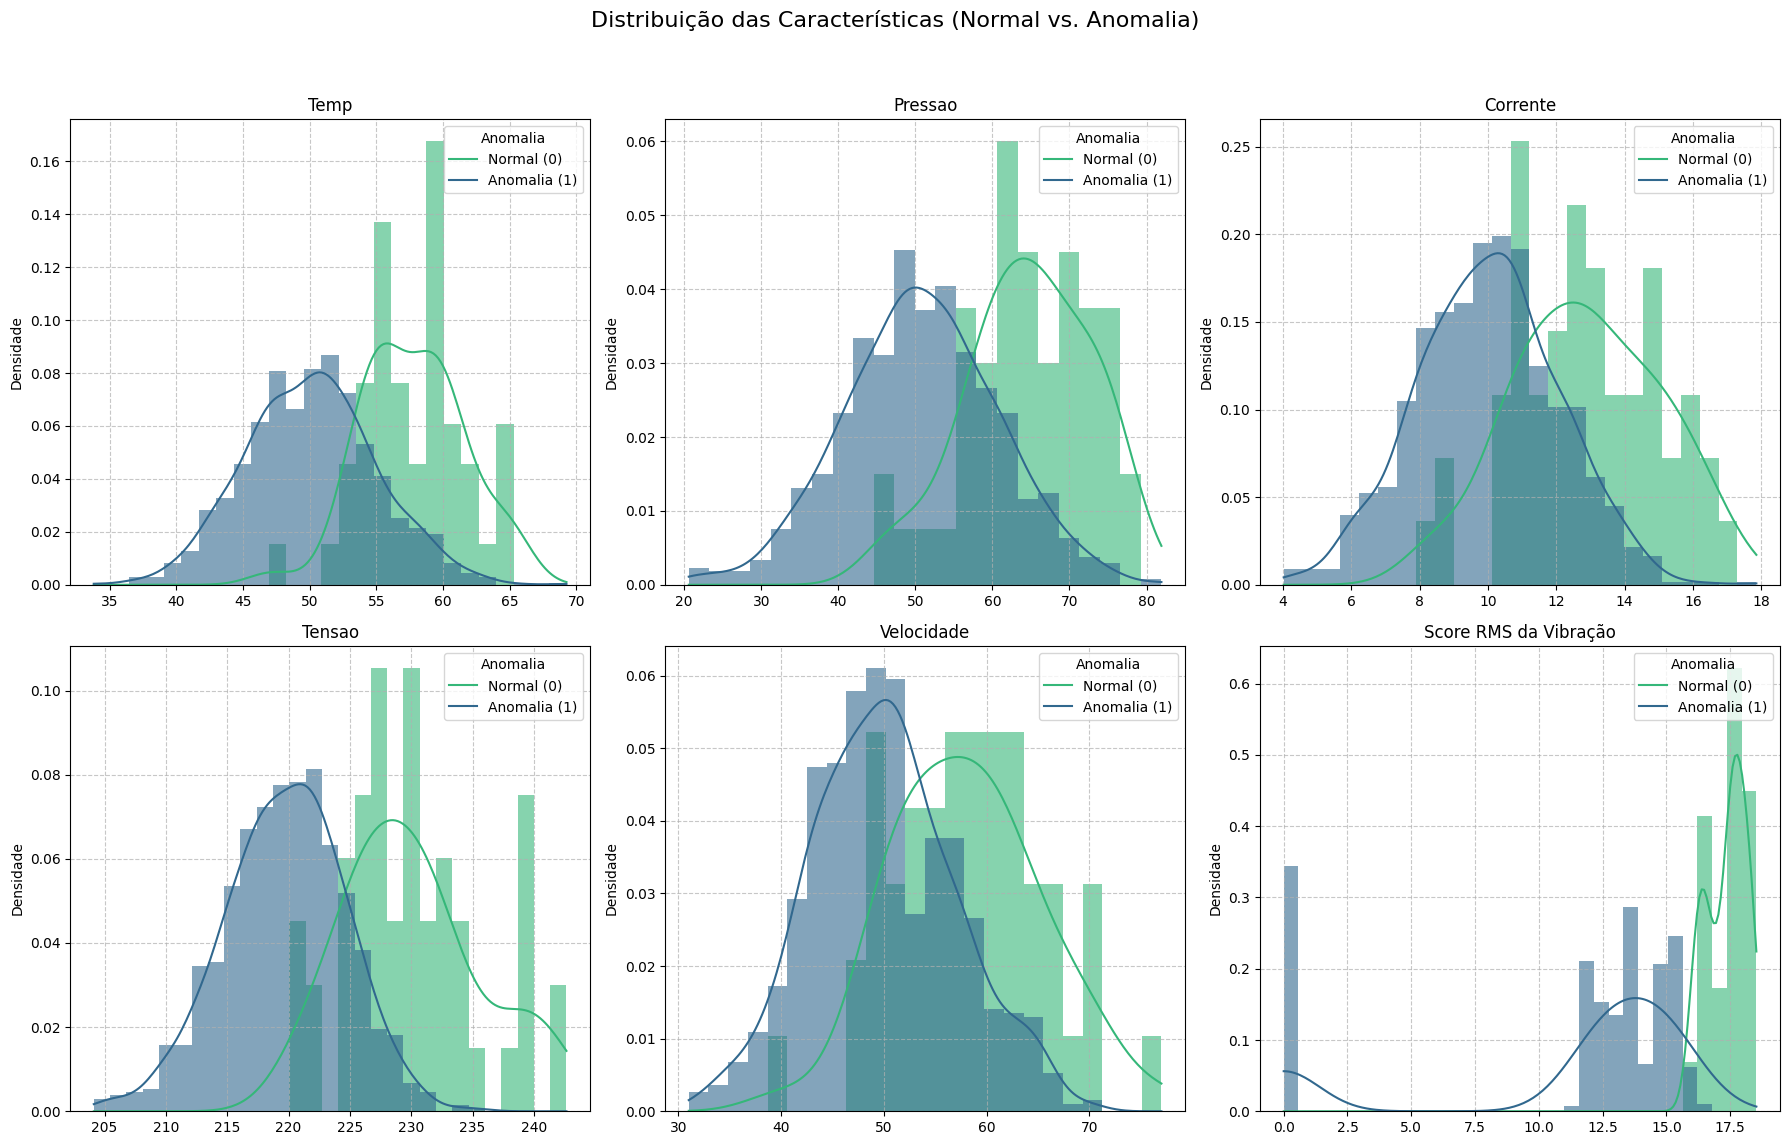

In [24]:
selected_metrics = ['Temp', 'Pressao', 'Corrente', 'Tensao', 'Velocidade', 'Vibracao_RMS']

plot_distribution_plots(df, y_real, optimal_params)

---

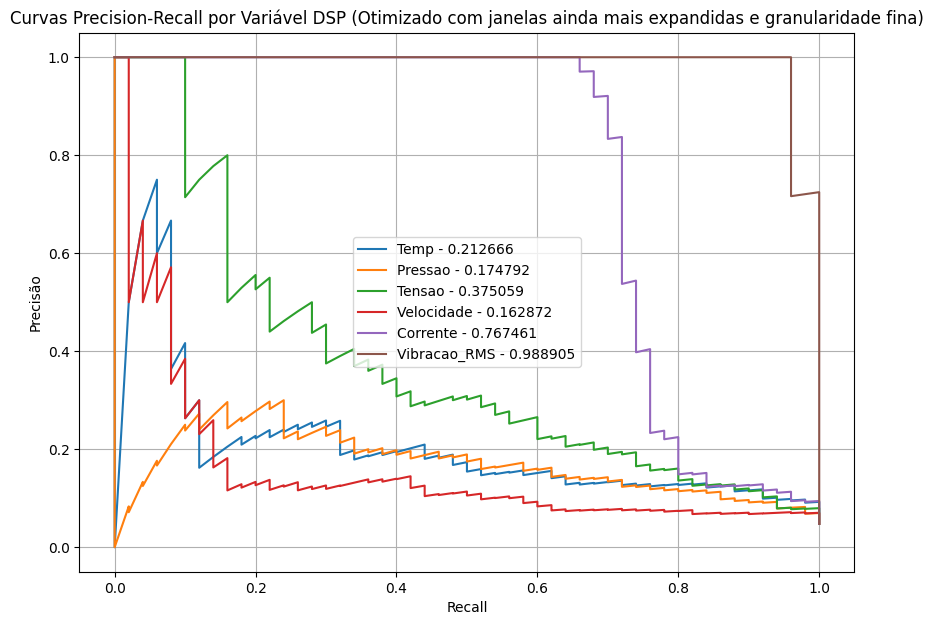

In [38]:
plot_pr_auc_curves(y_real, tecnicas_scores_unsupervised_window, resultados_pr_unsupervised_window, metrics_to_plot=selected_metrics)